In [6]:
import pandas as pd

df = pd.read_csv(
    "BIOGRID-GENE-107506-5.0.260.tab2.txt",
    sep="\t"
)

df.head()

,#BioGRID Interaction ID,Entrez Gene Interactor A,Entrez Gene Interactor B,BioGRID ID Interactor A,BioGRID ID Interactor B,Systematic Name Interactor A,Systematic Name Interactor B,Official Symbol Interactor A,Official Symbol Interactor B,Synonyms Interactor A,...,Pubmed ID,Organism Interactor A,Organism Interactor B,Throughput,Score,Modification,Phenotypes,Qualifications,Tags,Source Database
0,24390,1080,57120,107506,121384,tcag7.78,-,CFTR,GOPC,ABC35|ABCC7|CF|CFTR/MRP|MRP7|TNR-CFTR|dJ760C5.1,...,11707463,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID
1,253193,1080,3758,107506,109960,tcag7.78,-,CFTR,KCNJ1,ABC35|ABCC7|CF|CFTR/MRP|MRP7|TNR-CFTR|dJ760C5.1,...,14604981,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID
2,260079,1080,79849,107506,122940,tcag7.78,DLNB27,CFTR,PDZD3,ABC35|ABCC7|CF|CFTR/MRP|MRP7|TNR-CFTR|dJ760C5.1,...,12615054,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID
3,260080,1080,9368,107506,114769,tcag7.78,-,CFTR,SLC9A3R1,ABC35|ABCC7|CF|CFTR/MRP|MRP7|TNR-CFTR|dJ760C5.1,...,12615054,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID
4,275985,9368,1080,114769,107506,-,tcag7.78,SLC9A3R1,CFTR,EBP50|NHERF|NHERF-1|NHERF1|NPHLOP2,...,9613608,9606,9606,Low Throughput,-,-,-,-,-,BIOGRID


In [7]:
df.shape

df.columns.tolist()

['#BioGRID Interaction ID',
 'Entrez Gene Interactor A',
 'Entrez Gene Interactor B',
 'BioGRID ID Interactor A',
 'BioGRID ID Interactor B',
 'Systematic Name Interactor A',
 'Systematic Name Interactor B',
 'Official Symbol Interactor A',
 'Official Symbol Interactor B',
 'Synonyms Interactor A',
 'Synonyms Interactor B',
 'Experimental System',
 'Experimental System Type',
 'Author',
 'Pubmed ID',
 'Organism Interactor A',
 'Organism Interactor B',
 'Throughput',
 'Score',
 'Modification',
 'Phenotypes',
 'Qualifications',
 'Tags',
 'Source Database']

In [8]:
df["Experimental System Type"].value_counts()

Experimental System Type
physical    1946
genetic        3
Name: count, dtype: int64

In [9]:
# Keep only physical interactions
physical_df = df[
    df["Experimental System Type"] == "physical"
].copy()

In [10]:
physical_df["CFTR_Interactor"] = physical_df.apply(
    lambda row: (
        row["Official Symbol Interactor B"]
        if row["Official Symbol Interactor A"] == "CFTR"
        else row["Official Symbol Interactor A"]
    ),
    axis=1
)

In [11]:
interactor_summary = (
    physical_df
    .groupby("CFTR_Interactor")
    .agg(
        Interaction_Records=("#BioGRID Interaction ID", "count"),
        Publications=("Pubmed ID", "nunique"),
        Experimental_Systems=("Experimental System", "nunique")
    )
    .sort_values(
        by=["Publications", "Interaction_Records"],
        ascending=False
    )
)

interactor_summary.head(20)

,Interaction_Records,Publications,Experimental_Systems
CFTR_Interactor,,,
HSPA8,14,12,4
SLC9A3R1,15,10,4
VCP,10,8,2
STUB1,7,7,2
DERL1,6,5,2
HSP90AA1,6,5,3
HSPA4,6,5,2
CFTR,5,5,3
DNAJA1,5,5,3


In [12]:
interactor_summary = interactor_summary[
    interactor_summary.index != "CFTR"
]

In [13]:
interactor_summary.head(10)

,Interaction_Records,Publications,Experimental_Systems
CFTR_Interactor,,,
HSPA8,14,12,4
SLC9A3R1,15,10,4
VCP,10,8,2
STUB1,7,7,2
DERL1,6,5,2
HSP90AA1,6,5,3
HSPA4,6,5,2
DNAJA1,5,5,3
HSPB1,5,5,2


In [14]:
candidate_proteins = [
    "CFTR",
    "HSPA8",
    "SLC9A3R1",
    "VCP",
    "STUB1",
    "DERL1"
]

candidate_edges = physical_df[
    physical_df["Official Symbol Interactor A"].isin(candidate_proteins) &
    physical_df["Official Symbol Interactor B"].isin(candidate_proteins)
].copy()

candidate_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System",
        "Pubmed ID"
    ]
]

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System,Pubmed ID
3,CFTR,SLC9A3R1,Reconstituted Complex,12615054
4,SLC9A3R1,CFTR,Reconstituted Complex,9613608
5,CFTR,SLC9A3R1,Affinity Capture-Western,9613608
8,CFTR,HSPA8,Affinity Capture-Western,10075921
18,SLC9A3R1,CFTR,Affinity Capture-Western,10852925
19,SLC9A3R1,CFTR,Reconstituted Complex,12471024
24,CFTR,SLC9A3R1,Reconstituted Complex,9671706
29,SLC9A3R1,CFTR,Reconstituted Complex,9677412
30,SLC9A3R1,CFTR,Protein-peptide,9677412
31,CFTR,SLC9A3R1,Protein-peptide,9677412


In [15]:
candidate_edges["Protein_1"] = candidate_edges[
    ["Official Symbol Interactor A", "Official Symbol Interactor B"]
].min(axis=1)

candidate_edges["Protein_2"] = candidate_edges[
    ["Official Symbol Interactor A", "Official Symbol Interactor B"]
].max(axis=1)

pair_summary = (
    candidate_edges
    .groupby(["Protein_1", "Protein_2"])
    .agg(
        Interaction_Records=("#BioGRID Interaction ID", "count"),
        Publications=("Pubmed ID", "nunique"),
        Experimental_Systems=("Experimental System", "nunique")
    )
    .reset_index()
    .sort_values(
        ["Publications", "Interaction_Records"],
        ascending=False
    )
)

pair_summary = pair_summary[
    pair_summary["Protein_1"] != pair_summary["Protein_2"]
].copy()

pair_summary


,Protein_1,Protein_2,Interaction_Records,Publications,Experimental_Systems
2,CFTR,HSPA8,14,12,4
3,CFTR,SLC9A3R1,15,10,4
5,CFTR,VCP,10,8,2
4,CFTR,STUB1,7,7,2
1,CFTR,DERL1,6,5,2


In [16]:
iteration1_edges = pair_summary[
    ["Protein_1", "Protein_2"]
].copy()

iteration1_edges

,Protein_1,Protein_2
2,CFTR,HSPA8
3,CFTR,SLC9A3R1
5,CFTR,VCP
4,CFTR,STUB1
1,CFTR,DERL1


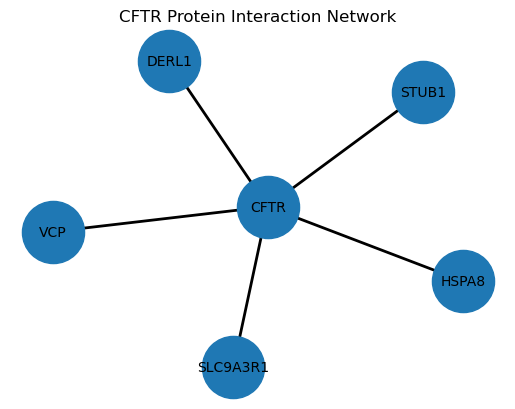

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_edges_from([
    ("CFTR", "HSPA8"),
    ("CFTR", "SLC9A3R1"),
    ("CFTR", "VCP"),
    ("CFTR", "STUB1"),
    ("CFTR", "DERL1")
])

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2000
)

nx.draw_networkx_edges(
    G,
    pos,
    width=2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.title("CFTR Protein Interaction Network")
plt.axis("off")
plt.show()

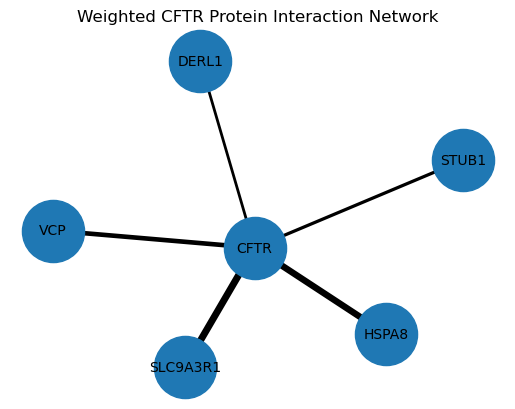

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

G_weighted = nx.Graph()

edges_with_weights = [
    ("CFTR", "HSPA8", 14),
    ("CFTR", "SLC9A3R1", 15),
    ("CFTR", "VCP", 10),
    ("CFTR", "STUB1", 7),
    ("CFTR", "DERL1", 6)
]

G_weighted.add_weighted_edges_from(edges_with_weights)

pos = nx.spring_layout(G_weighted, seed=42)

edge_widths = [
    G_weighted[u][v]["weight"] / 3
    for u, v in G_weighted.edges()
]

nx.draw_networkx_nodes(
    G_weighted,
    pos,
    node_size=2000
)

nx.draw_networkx_edges(
    G_weighted,
    pos,
    width=edge_widths
)

nx.draw_networkx_labels(
    G_weighted,
    pos,
    font_size=10
)

plt.title("Weighted CFTR Protein Interaction Network")
plt.axis("off")
plt.show()

In [19]:
top10_proteins = interactor_summary.head(10).index.tolist()

top10_proteins

['HSPA8',
 'SLC9A3R1',
 'VCP',
 'STUB1',
 'DERL1',
 'HSP90AA1',
 'HSPA4',
 'DNAJA1',
 'HSPB1',
 'CANX']

In [20]:
expanded_proteins = ["CFTR"] + top10_proteins

expanded_proteins

['CFTR',
 'HSPA8',
 'SLC9A3R1',
 'VCP',
 'STUB1',
 'DERL1',
 'HSP90AA1',
 'HSPA4',
 'DNAJA1',
 'HSPB1',
 'CANX']

In [21]:
expanded_edges = physical_df[
    physical_df["Official Symbol Interactor A"].isin(expanded_proteins) &
    physical_df["Official Symbol Interactor B"].isin(expanded_proteins)
].copy()

In [22]:
expanded_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System"
    ]
]

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System
3,CFTR,SLC9A3R1,Reconstituted Complex
4,SLC9A3R1,CFTR,Reconstituted Complex
5,CFTR,SLC9A3R1,Affinity Capture-Western
8,CFTR,HSPA8,Affinity Capture-Western
10,CFTR,DNAJA1,Affinity Capture-Western
...,...,...,...
1543,CFTR,HSP90AA1,Affinity Capture-MS
1544,CFTR,HSPB1,Affinity Capture-MS
1555,CFTR,HSPA8,Affinity Capture-MS
1577,CFTR,VCP,Affinity Capture-MS


In [23]:
non_cftr_edges = expanded_edges[
    (expanded_edges["Official Symbol Interactor A"] != "CFTR") &
    (expanded_edges["Official Symbol Interactor B"] != "CFTR")
]

non_cftr_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System"
    ]
]

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System


In [24]:
non_cftr_pairs = (
    non_cftr_edges[
        [
            "Official Symbol Interactor A",
            "Official Symbol Interactor B"
        ]
    ]
    .drop_duplicates()
)

non_cftr_pairs

,Official Symbol Interactor A,Official Symbol Interactor B


In [25]:
second_degree_edges = physical_df[
    (
        physical_df["Official Symbol Interactor A"].isin(expanded_proteins)
    ) |
    (
        physical_df["Official Symbol Interactor B"].isin(expanded_proteins)
    )
].copy()

In [26]:
second_degree_edges.shape

(1946, 25)

In [27]:
second_degree_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System"
    ]
].head(20)

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System
0,CFTR,GOPC,Two-hybrid
1,CFTR,KCNJ1,Affinity Capture-Western
2,CFTR,PDZD3,Reconstituted Complex
3,CFTR,SLC9A3R1,Reconstituted Complex
4,SLC9A3R1,CFTR,Reconstituted Complex
5,CFTR,SLC9A3R1,Affinity Capture-Western
6,STX1A,CFTR,Reconstituted Complex
7,STX1A,CFTR,Affinity Capture-Western
8,CFTR,HSPA8,Affinity Capture-Western
9,CFTR,DNAJB1,Affinity Capture-Western


In [28]:
import os

print("Jupyter is currently looking in:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Jupyter is currently looking in:
C:\Users\ANNA CAMILLE

Files in this folder:
['.anaconda', '.conda', '.dbvis', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'BIOGRID-GENE-107506-5.0.260.tab2.txt', 'BIOGRID-ORGANISM-Homo_sapiens-5.0.261.tab3.txt', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'expanded_bayesian_network.png', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'New folder', 'New folder python', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Thesis.ipynb', 'Videos']


In [29]:
import os

downloads = r"C:\Users\ANNA CAMILLE\Downloads"

print(os.listdir(downloads))

['.ipynb_checkpoints', '.Rhistory', '0213984c-fde7-40fa-a0ed-5235321ef691.jpg', '06MATH_Class_Syllabus (1).pdf', '06MATH_Class_Syllabus.pdf', '06MATH_pretest_answers.pdf', '06MATH_Pre_test.pdf', '07242026135149_CRCINDIncomplete_2513492.pdf', '07MATH_Class_Syllabus.pdf', '07Math_pretest_ans.pdf', '07MATH___7B_Pre_test.pdf', '100s-chart-for-groups-of-3.pdf', '12.2025 Private School Employee Handbook 12.2025 rvsd - Google Docs (1).pdf', '12.2025 Private School Employee Handbook 12.2025 rvsd - Google Docs.pdf', '12.2025 Private School New Employee Welcome Packet 12.2025 rvsd - Google Docs.pdf', '15e96fe6-fd05-4a0a-84d6-485bfa6b5c60.jpg', '1ae391f6-38dd-4498-904f-89470ffe02d9.jpg', '1aeb80ae-f776-4858-ab89-bf35f35e5764.jpg', '2 Matrix Algebra.pdf', '28647163-20a8-46ea-a29c-bb66b01f7374.jpg', '2bea08be-c0d5-403f-bd34-4b02ec3743e9.jpg', '2D&3D.R', '3. Multivariate Normal Model (1).pdf', '3. Multivariate Normal Model.pdf', '3. MVN.R', '37e5bde4-1508-4ca0-954c-801745588c93.jpg', '3d6affdf-01b7-

In [30]:
zip_path = r"C:\Users\ANNA CAMILLE\Downloads\BIOGRID-ORGANISM-5.0.261.tab3.zip"

In [31]:
import zipfile

zip_path = r"C:\Users\ANNA CAMILLE\Downloads\BIOGRID-ORGANISM-5.0.261.tab3.zip"

human_file = "BIOGRID-ORGANISM-Homo_sapiens-5.0.261.tab3.txt"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extract(human_file)

print("Human BioGRID file extracted!")

Human BioGRID file extracted!


In [32]:
import os

human_path = r"C:\Users\ANNA CAMILLE\BIOGRID-ORGANISM-Homo_sapiens-5.0.261.tab3.txt"

print("File exists:", os.path.exists(human_path))
print("File size:", round(os.path.getsize(human_path) / (1024**3), 2), "GB")

File exists: True
File size: 0.69 GB


In [33]:
import pandas as pd

human_path = r"C:\Users\ANNA CAMILLE\BIOGRID-ORGANISM-Homo_sapiens-5.0.261.tab3.txt"

sample = pd.read_csv(
    human_path,
    sep="\t",
    nrows=5
)

print("Number of columns:", len(sample.columns))
print("\nColumns:")
print(sample.columns.tolist())

Number of columns: 37

Columns:
['#BioGRID Interaction ID', 'Entrez Gene Interactor A', 'Entrez Gene Interactor B', 'BioGRID ID Interactor A', 'BioGRID ID Interactor B', 'Systematic Name Interactor A', 'Systematic Name Interactor B', 'Official Symbol Interactor A', 'Official Symbol Interactor B', 'Synonyms Interactor A', 'Synonyms Interactor B', 'Experimental System', 'Experimental System Type', 'Author', 'Publication Source', 'Organism ID Interactor A', 'Organism ID Interactor B', 'Throughput', 'Score', 'Modification', 'Qualifications', 'Tags', 'Source Database', 'SWISS-PROT Accessions Interactor A', 'TREMBL Accessions Interactor A', 'REFSEQ Accessions Interactor A', 'SWISS-PROT Accessions Interactor B', 'TREMBL Accessions Interactor B', 'REFSEQ Accessions Interactor B', 'Ontology Term IDs', 'Ontology Term Names', 'Ontology Term Categories', 'Ontology Term Qualifier IDs', 'Ontology Term Qualifier Names', 'Ontology Term Types', 'Organism Name Interactor A', 'Organism Name Interactor B'

In [34]:
with open(human_path, "r", encoding="utf-8") as f:
    row_count = sum(1 for _ in f) - 1

print("Number of interaction records:", row_count)

Number of interaction records: 1422529


In [35]:
import pandas as pd

proteins = [
    "CFTR",
    "HSPA8",
    "SLC9A3R1",
    "VCP",
    "STUB1",
    "DERL1"
]

matches = []

for chunk in pd.read_csv(
    human_path,
    sep="\t",
    chunksize=100000,
    low_memory=False
):
    filtered = chunk[
        chunk["Official Symbol Interactor A"].isin(proteins) |
        chunk["Official Symbol Interactor B"].isin(proteins)
    ]

    matches.append(filtered)

network_data = pd.concat(matches, ignore_index=True)

print("Matching interaction records:", len(network_data))

Matching interaction records: 10505


In [36]:
candidate_edges = network_data[
    network_data["Official Symbol Interactor A"].isin(proteins) &
    network_data["Official Symbol Interactor B"].isin(proteins)
].copy()

print("Interaction records among our six proteins:", len(candidate_edges))

Interaction records among our six proteins: 209


In [37]:
candidate_edges["Protein_1"] = candidate_edges[
    ["Official Symbol Interactor A", "Official Symbol Interactor B"]
].min(axis=1)

candidate_edges["Protein_2"] = candidate_edges[
    ["Official Symbol Interactor A", "Official Symbol Interactor B"]
].max(axis=1)

pair_summary = (
    candidate_edges
    .groupby(["Protein_1", "Protein_2"])
    .agg(
        Interaction_Records=("#BioGRID Interaction ID", "count"),
        Publications=("Publication Source", "nunique"),
        Experimental_Systems=("Experimental System", "nunique")
    )
    .reset_index()
    .sort_values(
        ["Protein_1", "Protein_2"]
    )
)

pair_summary

,Protein_1,Protein_2,Interaction_Records,Publications,Experimental_Systems
0,CFTR,CFTR,5,5,3
1,CFTR,DERL1,6,5,2
2,CFTR,HSPA8,14,12,4
3,CFTR,SLC9A3R1,15,10,4
4,CFTR,STUB1,7,7,2
5,CFTR,VCP,10,8,2
6,DERL1,DERL1,1,1,1
7,DERL1,HSPA8,1,1,1
8,DERL1,VCP,18,16,6
9,HSPA8,HSPA8,6,5,3


In [38]:
pair_summary_no_self = pair_summary[
    pair_summary["Protein_1"] != pair_summary["Protein_2"]
].copy()

print("Unique protein pairs:", len(pair_summary_no_self))

pair_summary_no_self

Unique protein pairs: 10


,Protein_1,Protein_2,Interaction_Records,Publications,Experimental_Systems
1,CFTR,DERL1,6,5,2
2,CFTR,HSPA8,14,12,4
3,CFTR,SLC9A3R1,15,10,4
4,CFTR,STUB1,7,7,2
5,CFTR,VCP,10,8,2
7,DERL1,HSPA8,1,1,1
8,DERL1,VCP,18,16,6
10,HSPA8,STUB1,52,37,11
11,HSPA8,VCP,7,7,3
14,STUB1,VCP,3,3,2


In [39]:
import networkx as nx
import matplotlib.pyplot as plt

G_expanded = nx.Graph()

# Add the six proteins as nodes
G_expanded.add_nodes_from(proteins)

# Add edges with BioGRID interaction-record counts as weights
for _, row in pair_summary_no_self.iterrows():
    G_expanded.add_edge(
        row["Protein_1"],
        row["Protein_2"],
        weight=row["Interaction_Records"]
    )

print("Number of nodes:", G_expanded.number_of_nodes())
print("Number of edges:", G_expanded.number_of_edges())

Number of nodes: 6
Number of edges: 10


In [40]:
for u, v, data in G_expanded.edges(data=True):
    print(f"{u} -- {v}: {data['weight']} records")

CFTR -- DERL1: 6 records
CFTR -- HSPA8: 14 records
CFTR -- SLC9A3R1: 15 records
CFTR -- STUB1: 7 records
CFTR -- VCP: 10 records
HSPA8 -- DERL1: 1 records
HSPA8 -- STUB1: 52 records
HSPA8 -- VCP: 7 records
VCP -- DERL1: 18 records
VCP -- STUB1: 3 records


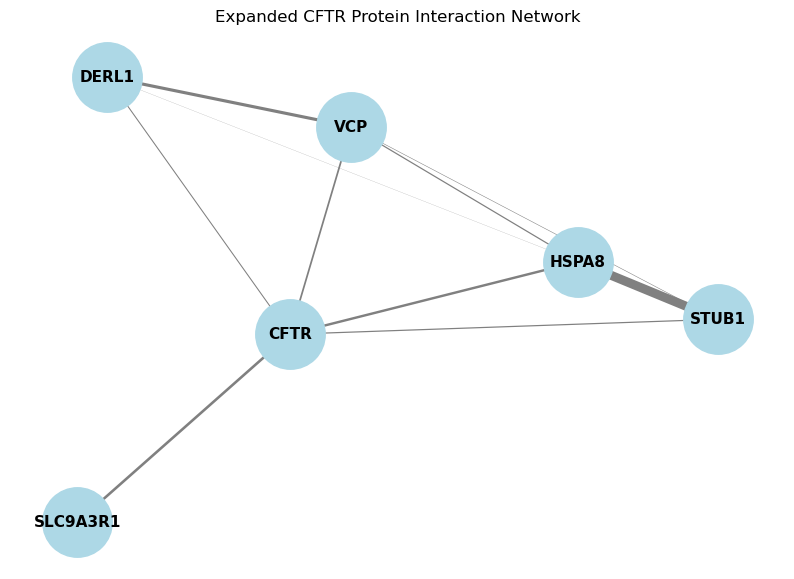

In [41]:
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(G_expanded, seed=42)

weights = [
    G_expanded[u][v]["weight"]
    for u, v in G_expanded.edges()
]

nx.draw_networkx(
    G_expanded,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    edge_color="gray",
    width=[w / 8 for w in weights],
    font_size=11,
    font_weight="bold"
)

plt.title("Expanded CFTR Protein Interaction Network")
plt.axis("off")
plt.show()

In [42]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
dag = nx.DiGraph()
dag.add_edges_from(learned_structure.edges())

# Clean, intentional layout
pos = {
    "CFTR": (-2.5, 1),
    "SLC9A3R1": (-2.5, 0),
    "VCP": (-2.5, -1),
    "STUB1": (0, 0),
    "HSPA8": (2.5, 1),
    "DERL1": (2.5, -1)
}

plt.figure(figsize=(11, 6.5))

# Nodes
nx.draw_networkx_nodes(
    dag,
    pos,
    node_size=4000,
    node_color="lightblue",
    edgecolors="black",
    linewidths=1.2
)

# Directed edges with large, obvious arrowheads
nx.draw_networkx_edges(
    dag,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=30,
    width=2.2,
    edge_color="black",
    node_size=4000,
    min_source_margin=12,
    min_target_margin=18,
    connectionstyle="arc3,rad=0.04"
)

# Labels
nx.draw_networkx_labels(
    dag,
    pos,
    font_size=11,
    font_weight="bold"
)

plt.title(
    "Learned Bayesian Network Structure",
    fontsize=15,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

NameError: name 'learned_structure' is not defined

In [ ]:
import pgmpy

print("pgmpy version:", pgmpy.__version__)

In [ ]:
from pgmpy.models import BayesianNetwork

print("BayesianNetwork imported successfully!")

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork

small_model = DiscreteBayesianNetwork([
    ("CFTR", "HSPA8")
])

print("Nodes:", list(small_model.nodes()))
print("Edges:", list(small_model.edges()))

In [ ]:
from pgmpy.factors.discrete import TabularCPD

cftr_cpd = TabularCPD(
    variable="CFTR",
    variable_card=2,
    values=[
        [0.70],
        [0.30]
    ],
    state_names={
        "CFTR": ["0", "1"]
    }
)

print(cftr_cpd)

In [ ]:
hspa8_cpd = TabularCPD(
    variable="HSPA8",
    variable_card=2,
    values=[
        [0.80, 0.30],
        [0.20, 0.70]
    ],
    evidence=["CFTR"],
    evidence_card=[2],
    state_names={
        "HSPA8": ["0", "1"],
        "CFTR": ["0", "1"]
    }
)

print(hspa8_cpd)

In [ ]:
small_model.add_cpds(cftr_cpd, hspa8_cpd)

print("CPDs added successfully!")
print()
print(small_model.get_cpds())

In [ ]:
print("Model valid:", small_model.check_model())

In [ ]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(small_model)

result = inference.query(
    variables=["HSPA8"],
    evidence={"CFTR": "1"}
)

print(result)

In [ ]:
# Check for missing values in the interaction data

missing_values = candidate_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System",
        "Experimental System Type",
        "Organism ID Interactor A",
        "Organism ID Interactor B"
    ]
].isna().sum()

print(missing_values)

In [ ]:
# Check for exact duplicate interaction records

duplicate_count = candidate_edges.duplicated().sum()

print("Duplicate records:", duplicate_count)

In [ ]:
# Create the cleaned edge list for the six-protein network

edge_list = pair_summary_no_self[
    [
        "Protein_1",
        "Protein_2",
        "Interaction_Records",
        "Publications",
        "Experimental_Systems"
    ]
].copy()

print("Clean edge list:")
display(edge_list)

In [43]:
# Examine the experimental systems represented
# in the 209 interaction records

experimental_systems = (
    candidate_edges["Experimental System"]
    .value_counts()
    .reset_index()
)

experimental_systems.columns = [
    "Experimental_System",
    "Interaction_Records"
]

print("Number of experimental systems:",
      len(experimental_systems))

display(experimental_systems)

Number of experimental systems: 14


,Experimental_System,Interaction_Records
0,Affinity Capture-Western,58
1,Biochemical Activity,41
2,Affinity Capture-MS,36
3,Reconstituted Complex,33
4,Co-crystal Structure,10
5,Co-fractionation,6
6,Protein-peptide,6
7,Cross-Linking-MS (XL-MS),6
8,Two-hybrid,3
9,Affinity Capture-Luminescence,3


In [44]:
# Examine the experimental system types in our candidate interactions

candidate_edges[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System",
        "Experimental System Type",
        "Throughput",
        "Score"
    ]
].head(20)

,Official Symbol Interactor A,Official Symbol Interactor B,Experimental System,Experimental System Type,Throughput,Score
23,SLC9A3R1,SLC9A3R1,Reconstituted Complex,physical,Low Throughput,-
34,VCP,VCP,Co-fractionation,physical,Low Throughput,-
39,CFTR,SLC9A3R1,Reconstituted Complex,physical,Low Throughput,-
56,SLC9A3R1,CFTR,Reconstituted Complex,physical,Low Throughput,-
57,CFTR,SLC9A3R1,Affinity Capture-Western,physical,Low Throughput,-
75,CFTR,HSPA8,Affinity Capture-Western,physical,Low Throughput,-
110,SLC9A3R1,CFTR,Affinity Capture-Western,physical,Low Throughput,-
112,VCP,VCP,Affinity Capture-Western,physical,Low Throughput,-
115,SLC9A3R1,CFTR,Reconstituted Complex,physical,Low Throughput,-
130,SLC9A3R1,SLC9A3R1,Far Western,physical,Low Throughput,-


In [45]:
# Examine the publication information for our candidate interactions

candidate_edges[
    [
        "#BioGRID Interaction ID",
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Publication Source",
        "Experimental System"
    ]
].head(20)

,#BioGRID Interaction ID,Official Symbol Interactor A,Official Symbol Interactor B,Publication Source,Experimental System
23,251983,SLC9A3R1,SLC9A3R1,PUBMED:15070904,Reconstituted Complex
34,258255,VCP,VCP,PUBMED:12807884,Co-fractionation
39,260080,CFTR,SLC9A3R1,PUBMED:12615054,Reconstituted Complex
56,275985,SLC9A3R1,CFTR,PUBMED:9613608,Reconstituted Complex
57,275986,CFTR,SLC9A3R1,PUBMED:9613608,Affinity Capture-Western
75,278424,CFTR,HSPA8,PUBMED:10075921,Affinity Capture-Western
110,288282,SLC9A3R1,CFTR,PUBMED:10852925,Affinity Capture-Western
112,301594,VCP,VCP,PUBMED:17525332,Affinity Capture-Western
115,302278,SLC9A3R1,CFTR,PUBMED:12471024,Reconstituted Complex
130,302810,SLC9A3R1,SLC9A3R1,PUBMED:11046132,Far Western


In [46]:
# Count unique publications for the six selected proteins

publication_counts = (
    candidate_edges
    .groupby("Publication Source")
    .size()
    .reset_index(name="Interaction_Records")
    .sort_values("Interaction_Records", ascending=False)
)

print("Number of unique publications:",
      publication_counts["Publication Source"].nunique())

display(publication_counts.head(20))

Number of unique publications: 130


,Publication Source,Interaction_Records
81,PUBMED:26618866,5
100,PUBMED:31324722,5
8,PUBMED:11146634,4
37,PUBMED:17272822,4
98,PUBMED:29568061,4
35,PUBMED:17110338,4
117,PUBMED:36027913,4
34,PUBMED:16954204,4
113,PUBMED:35398354,4
30,PUBMED:16621797,4


In [47]:
# Count how many unique publications contain each protein

protein_publication_counts = {}

for protein in proteins:
    rows = candidate_edges[
        (candidate_edges["Official Symbol Interactor A"] == protein) |
        (candidate_edges["Official Symbol Interactor B"] == protein)
    ]
    
    protein_publication_counts[protein] = rows["Publication Source"].nunique()

protein_publication_counts

{'CFTR': 33, 'HSPA8': 57, 'SLC9A3R1': 14, 'VCP': 46, 'STUB1': 66, 'DERL1': 21}

In [48]:
# Create a publication-level observation matrix

publication_protein_data = []

for publication, group in candidate_edges.groupby("Publication Source"):
    
    row = {"Publication": publication}
    
    for protein in proteins:
        present = (
            (group["Official Symbol Interactor A"] == protein) |
            (group["Official Symbol Interactor B"] == protein)
        ).any()
        
        row[protein] = int(present)
    
    publication_protein_data.append(row)

publication_matrix = pd.DataFrame(publication_protein_data)

print("Number of observations:", len(publication_matrix))
print("Number of protein variables:", len(proteins))

display(publication_matrix.head(20))

Number of observations: 130
Number of protein variables: 6


,Publication,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1
0,PUBMED:10075921,1,1,0,0,0,0
1,PUBMED:10330192,0,1,0,0,1,0
2,PUBMED:10350210,0,0,0,1,0,0
3,PUBMED:10666020,1,1,0,0,0,0
4,PUBMED:10852925,1,0,1,0,0,0
5,PUBMED:10982807,1,1,0,0,0,0
6,PUBMED:11046132,0,0,1,0,0,0
7,PUBMED:11051556,1,0,0,0,0,0
8,PUBMED:11146634,1,1,0,0,1,0
9,PUBMED:11533036,0,0,1,0,0,0


In [49]:
# Check how often each protein appears across publications

protein_frequencies = publication_matrix[proteins].sum().sort_values(
    ascending=False
)

print("Number of publications containing each protein:")
display(protein_frequencies)

print("\nProportion of publications containing each protein:")
display((protein_frequencies / len(publication_matrix)).round(3))

Number of publications containing each protein:


STUB1       66
HSPA8       57
VCP         46
CFTR        33
DERL1       21
SLC9A3R1    14
dtype: int64


Proportion of publications containing each protein:


STUB1       0.508
HSPA8       0.438
VCP         0.354
CFTR        0.254
DERL1       0.162
SLC9A3R1    0.108
dtype: float64

In [50]:
# Prepare the publication-level data for pgmpy

pgm_data = publication_matrix[proteins].copy()

print("PGM data shape:", pgm_data.shape)
print()
display(pgm_data.head())

PGM data shape: (130, 6)



,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1
0,1,1,0,0,0,0
1,0,1,0,0,1,0
2,0,0,0,1,0,0
3,1,1,0,0,0,0
4,1,0,1,0,0,0


In [51]:
from pgmpy.estimators import HillClimbSearch, BIC

# Create the structure-learning estimator
estimator = HillClimbSearch(pgm_data)

# Use BIC to score candidate network structures
bic = BIC(pgm_data)

# Learn the directed structure
learned_structure = estimator.estimate(
    scoring_method=bic
)

print("Learned edges:")
print(list(learned_structure.edges()))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges:
[('CFTR', 'SLC9A3R1'), ('CFTR', 'STUB1'), ('SLC9A3R1', 'STUB1'), ('VCP', 'STUB1'), ('STUB1', 'DERL1'), ('STUB1', 'HSPA8')]


In [52]:
from pgmpy.models import DiscreteBayesianNetwork

# Create the Bayesian network from the learned structure
pgm_model = DiscreteBayesianNetwork(
    list(learned_structure.edges())
)

print("Nodes:")
print(list(pgm_model.nodes()))

print("\nDirected edges:")
print(list(pgm_model.edges()))

Nodes:
['CFTR', 'SLC9A3R1', 'STUB1', 'VCP', 'DERL1', 'HSPA8']

Directed edges:
[('CFTR', 'SLC9A3R1'), ('CFTR', 'STUB1'), ('SLC9A3R1', 'STUB1'), ('STUB1', 'DERL1'), ('STUB1', 'HSPA8'), ('VCP', 'STUB1')]


In [53]:
from pgmpy.estimators import MaximumLikelihoodEstimator

# Learn the conditional probability distributions from the data
pgm_model.fit(
    pgm_data,
    estimator=MaximumLikelihoodEstimator
)

print("CPDs learned successfully.")
print()

for cpd in pgm_model.get_cpds():
    print(cpd)
    print()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


CPDs learned successfully.

+---------+----------+
| CFTR(0) | 0.746154 |
+---------+----------+
| CFTR(1) | 0.253846 |
+---------+----------+

+-------------+----------------------+---------------------+
| CFTR        | CFTR(0)              | CFTR(1)             |
+-------------+----------------------+---------------------+
| SLC9A3R1(0) | 0.9587628865979382   | 0.696969696969697   |
+-------------+----------------------+---------------------+
| SLC9A3R1(1) | 0.041237113402061855 | 0.30303030303030304 |
+-------------+----------------------+---------------------+

+----------+---------------------+---------------------+-----+---------------------+-------------+-------------+
| CFTR     | CFTR(0)             | CFTR(0)             | ... | CFTR(1)             | CFTR(1)     | CFTR(1)     |
+----------+---------------------+---------------------+-----+---------------------+-------------+-------------+
| SLC9A3R1 | SLC9A3R1(0)         | SLC9A3R1(0)         | ... | SLC9A3R1(0)         | SLC9

In [54]:
from pgmpy.estimators import BayesianEstimator

pgm_model.fit(
    pgm_data,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

for cpd in pgm_model.get_cpds():
    print(cpd)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


+---------+----------+
| CFTR(0) | 0.728571 |
+---------+----------+
| CFTR(1) | 0.271429 |
+---------+----------+
+-------------+---------------------+---------------------+
| CFTR        | CFTR(0)             | CFTR(1)             |
+-------------+---------------------+---------------------+
| SLC9A3R1(0) | 0.9362745098039216  | 0.6710526315789473  |
+-------------+---------------------+---------------------+
| SLC9A3R1(1) | 0.06372549019607843 | 0.32894736842105265 |
+-------------+---------------------+---------------------+
+----------+---------------------+---------------------+-----+---------------------+---------------------+
| CFTR     | CFTR(0)             | CFTR(0)             | ... | CFTR(1)             | CFTR(1)             |
+----------+---------------------+---------------------+-----+---------------------+---------------------+
| SLC9A3R1 | SLC9A3R1(0)         | SLC9A3R1(0)         | ... | SLC9A3R1(1)         | SLC9A3R1(1)         |
+----------+---------------------+---

In [55]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(pgm_model)

for protein in pgm_data.columns:
    result = inference.query([protein])
    print(protein)
    print(result)

CFTR
+---------+-------------+
| CFTR    |   phi(CFTR) |
+=========+=============+
| CFTR(0) |      0.7286 |
+---------+-------------+
| CFTR(1) |      0.2714 |
+---------+-------------+
HSPA8
+----------+--------------+
| HSPA8    |   phi(HSPA8) |
+==========+==============+
| HSPA8(0) |       0.5512 |
+----------+--------------+
| HSPA8(1) |       0.4488 |
+----------+--------------+
SLC9A3R1
+-------------+-----------------+
| SLC9A3R1    |   phi(SLC9A3R1) |
+=============+=================+
| SLC9A3R1(0) |          0.8643 |
+-------------+-----------------+
| SLC9A3R1(1) |          0.1357 |
+-------------+-----------------+
VCP
+--------+------------+
| VCP    |   phi(VCP) |
+========+============+
| VCP(0) |     0.6357 |
+--------+------------+
| VCP(1) |     0.3643 |
+--------+------------+
STUB1
+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.4720 |
+----------+--------------+
| STUB1(1) |       0.5280 |
+----------+------

In [56]:
# Check whether the Bayesian network is valid

model_valid = pgm_model.check_model()

print("Model valid:", model_valid)

Model valid: True


In [57]:
result = inference.query(
    variables=["STUB1"],
    evidence={"CFTR": 1}
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.7101 |
+----------+--------------+
| STUB1(1) |       0.2899 |
+----------+--------------+


In [58]:
result = inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "VCP": 1
    }
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.8012 |
+----------+--------------+
| STUB1(1) |       0.1988 |
+----------+--------------+


In [59]:
from pgmpy.inference import VariableElimination

# Create an inference engine for the Bayesian network
inference = VariableElimination(pgm_model)

# Query the probability of SLC9A3R1 given CFTR = 1
result = inference.query(
    variables=["SLC9A3R1"],
    evidence={"CFTR": 1}
)

print(result)

+-------------+-----------------+
| SLC9A3R1    |   phi(SLC9A3R1) |
+=============+=================+
| SLC9A3R1(0) |          0.6711 |
+-------------+-----------------+
| SLC9A3R1(1) |          0.3289 |
+-------------+-----------------+


In [60]:
# Query the probability of STUB1 given CFTR = 1

result = inference.query(
    variables=["STUB1"],
    evidence={"CFTR": 1}
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.7101 |
+----------+--------------+
| STUB1(1) |       0.2899 |
+----------+--------------+


In [61]:
# Query the probability of STUB1 without any evidence

result = inference.query(
    variables=["STUB1"]
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.4720 |
+----------+--------------+
| STUB1(1) |       0.5280 |
+----------+--------------+


In [62]:
# Query STUB1 given both CFTR and SLC9A3R1

result = inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "SLC9A3R1": 1
    }
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.8983 |
+----------+--------------+
| STUB1(1) |       0.1017 |
+----------+--------------+


In [63]:
# Examine observations where both CFTR and SLC9A3R1 are present

both_present = publication_matrix[
    (publication_matrix["CFTR"] == 1) &
    (publication_matrix["SLC9A3R1"] == 1)
]

print("Observations with CFTR = 1 and SLC9A3R1 = 1:",
      len(both_present))

display(both_present)

Observations with CFTR = 1 and SLC9A3R1 = 1: 10


,Publication,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1
4,PUBMED:10852925,1,0,1,0,0,0
12,PUBMED:12403779,1,0,1,0,0,0
13,PUBMED:12471024,1,0,1,0,0,0
16,PUBMED:12615054,1,0,1,0,0,0
35,PUBMED:17110338,1,1,1,1,0,0
81,PUBMED:26618866,1,1,1,1,0,1
100,PUBMED:31324722,1,1,1,1,0,0
127,PUBMED:9613608,1,0,1,0,0,0
128,PUBMED:9671706,1,0,1,0,0,0
129,PUBMED:9677412,1,0,1,0,0,0


In [64]:
# Examine how many observations exist for each parent combination of STUB1

stub1_parent_counts = (
    pgm_data
    .groupby(["CFTR", "SLC9A3R1", "VCP"])
    .size()
    .reset_index(name="Observations")
)

display(stub1_parent_counts)

,CFTR,SLC9A3R1,VCP,Observations
0,0,0,0,56
1,0,0,1,37
2,0,1,0,4
3,1,0,0,17
4,1,0,1,6
5,1,1,0,7
6,1,1,1,3


In [70]:
# Display only the learned CPD for STUB1

stub1_cpd = pgm_model.get_cpds("STUB1")

print(stub1_cpd)

+----------+---------------------+---------------------+-----+---------------------+---------------------+
| CFTR     | CFTR(0)             | CFTR(0)             | ... | CFTR(1)             | CFTR(1)             |
+----------+---------------------+---------------------+-----+---------------------+---------------------+
| SLC9A3R1 | SLC9A3R1(0)         | SLC9A3R1(0)         | ... | SLC9A3R1(1)         | SLC9A3R1(1)         |
+----------+---------------------+---------------------+-----+---------------------+---------------------+
| VCP      | VCP(0)              | VCP(1)              | ... | VCP(0)              | VCP(1)              |
+----------+---------------------+---------------------+-----+---------------------+---------------------+
| STUB1(0) | 0.04585152838427948 | 0.9052287581699346  | ... | 0.9242424242424242  | 0.8529411764705882  |
+----------+---------------------+---------------------+-----+---------------------+---------------------+
| STUB1(1) | 0.9541484716157205  | 0.

In [71]:
from pgmpy.estimators import BayesianEstimator

# Re-estimate the CPDs using Bayesian parameter estimation
pgm_model.fit(
    pgm_data,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

print("Bayesian CPDs learned successfully.")
print()

for cpd in pgm_model.get_cpds():
    print(cpd)
    print()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


Bayesian CPDs learned successfully.

+---------+----------+
| CFTR(0) | 0.728571 |
+---------+----------+
| CFTR(1) | 0.271429 |
+---------+----------+

+-------------+---------------------+---------------------+
| CFTR        | CFTR(0)             | CFTR(1)             |
+-------------+---------------------+---------------------+
| SLC9A3R1(0) | 0.9362745098039216  | 0.6710526315789473  |
+-------------+---------------------+---------------------+
| SLC9A3R1(1) | 0.06372549019607843 | 0.32894736842105265 |
+-------------+---------------------+---------------------+

+----------+---------------------+---------------------+-----+---------------------+---------------------+
| CFTR     | CFTR(0)             | CFTR(0)             | ... | CFTR(1)             | CFTR(1)             |
+----------+---------------------+---------------------+-----+---------------------+---------------------+
| SLC9A3R1 | SLC9A3R1(0)         | SLC9A3R1(0)         | ... | SLC9A3R1(1)         | SLC9A3R1(1)         

In [72]:
# Validate the Bayesian network after Bayesian parameter estimation

model_valid = pgm_model.check_model()

print("Model valid:", model_valid)

Model valid: True


In [73]:
# Create the inference engine using the updated Bayesian CPDs

inference = VariableElimination(pgm_model)

# Query STUB1 given CFTR = 1 and SLC9A3R1 = 1
result = inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "SLC9A3R1": 1
    }
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.8983 |
+----------+--------------+
| STUB1(1) |       0.1017 |
+----------+--------------+


In [74]:
# Display the final learned network structure

print("Number of nodes:", pgm_model.number_of_nodes())
print("Number of edges:", pgm_model.number_of_edges())

print("\nDirected edges:")
for edge in pgm_model.edges():
    print(f"{edge[0]} -> {edge[1]}")

Number of nodes: 6
Number of edges: 6

Directed edges:
CFTR -> SLC9A3R1
CFTR -> STUB1
SLC9A3R1 -> STUB1
STUB1 -> DERL1
STUB1 -> HSPA8
VCP -> STUB1


In [75]:
# Proteins selected for the expanded model

expanded_proteins = [
    "CFTR",
    "HSPA8",
    "SLC9A3R1",
    "VCP",
    "STUB1",
    "DERL1",
    "HSP90AA1",
    "HSPA4",
    "DNAJA1",
    "HSPB1",
    "CANX"
]

# Check the number of publications containing each protein

expanded_publication_counts = {}

for protein in expanded_proteins:
    rows = network_data[
        (network_data["Official Symbol Interactor A"] == protein) |
        (network_data["Official Symbol Interactor B"] == protein)
    ]
    
    expanded_publication_counts[protein] = (
        rows["Publication Source"].nunique()
    )

print("Publication counts for expanded protein set:")

for protein, count in expanded_publication_counts.items():
    print(f"{protein}: {count}")

Publication counts for expanded protein set:
CFTR: 84
HSPA8: 722
SLC9A3R1: 114
VCP: 596
STUB1: 560
DERL1: 113
HSP90AA1: 57
HSPA4: 80
DNAJA1: 14
HSPB1: 11
CANX: 11


In [76]:
# Create the expanded publication-level observation matrix

expanded_publication_data = []

for publication, group in network_data.groupby("Publication Source"):
    
    row = {"Publication": publication}
    
    for protein in expanded_proteins:
        present = (
            (group["Official Symbol Interactor A"] == protein) |
            (group["Official Symbol Interactor B"] == protein)
        ).any()
        
        row[protein] = int(present)
    
    expanded_publication_data.append(row)

expanded_publication_matrix = pd.DataFrame(
    expanded_publication_data
)

print(
    "Number of observations:",
    len(expanded_publication_matrix)
)

print(
    "Number of protein variables:",
    len(expanded_proteins)
)

display(expanded_publication_matrix.head(10))

Number of observations: 1668
Number of protein variables: 11


,Publication,CFTR,HSPA8,SLC9A3R1,VCP,STUB1,DERL1,HSP90AA1,HSPA4,DNAJA1,HSPB1,CANX
0,DOI:10.1101/2020.08.28.269175,0,0,0,0,0,1,0,0,0,0,0
1,DOI:10.1101/2020.08.28.272955,0,1,1,1,1,1,0,0,0,0,0
2,DOI:10.1101/2020.09.03.282103,0,1,1,0,1,1,0,0,0,0,0
3,DOI:10.1101/2020.12.31.424961,0,1,0,0,0,0,0,0,0,0,0
4,DOI:10.1101/2022.01.18.476803,1,0,0,0,0,0,0,0,0,0,0
5,DOI:10.1101/2022.09.27.509702,0,1,0,1,0,0,0,0,0,0,0
6,DOI:10.1101/2022.10.19.512927,0,0,1,0,0,0,0,0,0,0,0
7,DOI:10.1101/2023.05.15.540806,0,1,0,0,0,0,0,0,0,0,0
8,DOI:10.1101/2023.12.03.569805,0,0,0,0,1,0,0,0,0,0,0
9,PUBMED:10075921,1,1,0,0,0,0,0,0,1,0,0


In [77]:
# Check protein frequencies in the expanded dataset

expanded_frequencies = (
    expanded_publication_matrix[expanded_proteins]
    .sum()
    .sort_values(ascending=False)
)

expanded_proportions = (
    expanded_frequencies / len(expanded_publication_matrix)
).round(3)

print("Number of publications containing each protein:")
display(expanded_frequencies)

print("Proportion of publications containing each protein:")
display(expanded_proportions)

Number of publications containing each protein:


HSPA8       722
VCP         596
STUB1       560
SLC9A3R1    114
DERL1       113
CFTR         84
HSPA4        80
HSP90AA1     57
DNAJA1       14
HSPB1        11
CANX         11
dtype: int64

Proportion of publications containing each protein:


HSPA8       0.433
VCP         0.357
STUB1       0.336
SLC9A3R1    0.068
DERL1       0.068
CFTR        0.050
HSPA4       0.048
HSP90AA1    0.034
DNAJA1      0.008
HSPB1       0.007
CANX        0.007
dtype: float64

In [78]:
from pgmpy.estimators import HillClimbSearch, BIC

# Create the structure-learning estimator
expanded_estimator = HillClimbSearch(expanded_publication_matrix[expanded_proteins])

# Learn the directed network structure using BIC
expanded_structure = expanded_estimator.estimate(
    scoring_method=BIC(expanded_publication_matrix[expanded_proteins])
)

print("Learned edges:")
for edge in expanded_structure.edges():
    print(f"{edge[0]} -> {edge[1]}")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges:
CFTR -> STUB1
HSPA8 -> STUB1
HSPA8 -> CFTR
HSPA8 -> DNAJA1
SLC9A3R1 -> STUB1
SLC9A3R1 -> HSPA8
VCP -> STUB1
VCP -> HSPA8
VCP -> CFTR
VCP -> DERL1
VCP -> HSPB1
STUB1 -> HSPA4
STUB1 -> HSP90AA1
DERL1 -> STUB1
DERL1 -> HSPA8
HSP90AA1 -> HSPB1
HSPA4 -> HSP90AA1
HSPB1 -> DNAJA1
HSPB1 -> CANX


In [79]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator

# Create the expanded Bayesian network
expanded_pgm = DiscreteBayesianNetwork(
    list(expanded_structure.edges())
)

# Learn the CPDs using Bayesian parameter estimation
expanded_pgm.fit(
    expanded_publication_matrix[expanded_proteins],
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

print("Expanded Bayesian network fitted successfully.")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


Expanded Bayesian network fitted successfully.


In [80]:
# Validate the expanded Bayesian network

expanded_valid = expanded_pgm.check_model()

print("Expanded model valid:", expanded_valid)

Expanded model valid: True


In [81]:
# Examine the number of parents for each protein

parent_counts = {
    protein: len(list(expanded_pgm.predecessors(protein)))
    for protein in expanded_pgm.nodes()
}

parent_counts = pd.Series(parent_counts).sort_values(ascending=False)

print("Number of parents for each protein:")
display(parent_counts)

Number of parents for each protein:


STUB1       5
HSPA8       3
CFTR        2
DNAJA1      2
HSPB1       2
HSP90AA1    2
DERL1       1
HSPA4       1
CANX        1
SLC9A3R1    0
VCP         0
dtype: int64

In [82]:
# Create an inference engine for the expanded PGM

expanded_inference = VariableElimination(expanded_pgm)

# Query the marginal probability of CFTR
result = expanded_inference.query(
    variables=["CFTR"]
)

print(result)

+---------+-------------+
| CFTR    |   phi(CFTR) |
+=========+=============+
| CFTR(0) |      0.9471 |
+---------+-------------+
| CFTR(1) |      0.0529 |
+---------+-------------+


In [83]:
# Query CFTR given HSPA8 = 1

result = expanded_inference.query(
    variables=["CFTR"],
    evidence={"HSPA8": 1}
)

print(result)

+---------+-------------+
| CFTR    |   phi(CFTR) |
+=========+=============+
| CFTR(0) |      0.9731 |
+---------+-------------+
| CFTR(1) |      0.0269 |
+---------+-------------+


In [84]:
# Query CFTR given VCP = 1

result = expanded_inference.query(
    variables=["CFTR"],
    evidence={"VCP": 1}
)

print(result)

+---------+-------------+
| CFTR    |   phi(CFTR) |
+=========+=============+
| CFTR(0) |      0.9774 |
+---------+-------------+
| CFTR(1) |      0.0226 |
+---------+-------------+


In [85]:
# Query CFTR given both HSPA8 and VCP

result = expanded_inference.query(
    variables=["CFTR"],
    evidence={
        "HSPA8": 1,
        "VCP": 1
    }
)

print(result)

+---------+-------------+
| CFTR    |   phi(CFTR) |
+=========+=============+
| CFTR(0) |      0.9565 |
+---------+-------------+
| CFTR(1) |      0.0435 |
+---------+-------------+


In [86]:
result = expanded_inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1
    }
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.8437 |
+----------+--------------+
| STUB1(1) |       0.1563 |
+----------+--------------+


In [87]:
result = expanded_inference.query(
    variables=["STUB1"]
)

print(result)


+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.6589 |
+----------+--------------+
| STUB1(1) |       0.3411 |
+----------+--------------+


In [88]:
result = expanded_inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "VCP": 1
    }
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.7348 |
+----------+--------------+
| STUB1(1) |       0.2652 |
+----------+--------------+


In [89]:
result = expanded_inference.query(
    variables=["STUB1"],
    evidence={
        "CFTR": 1,
        "HSPA8": 1,
        "VCP": 1
    }
)

print(result)

+----------+--------------+
| STUB1    |   phi(STUB1) |
+==========+==============+
| STUB1(0) |       0.6448 |
+----------+--------------+
| STUB1(1) |       0.3552 |
+----------+--------------+


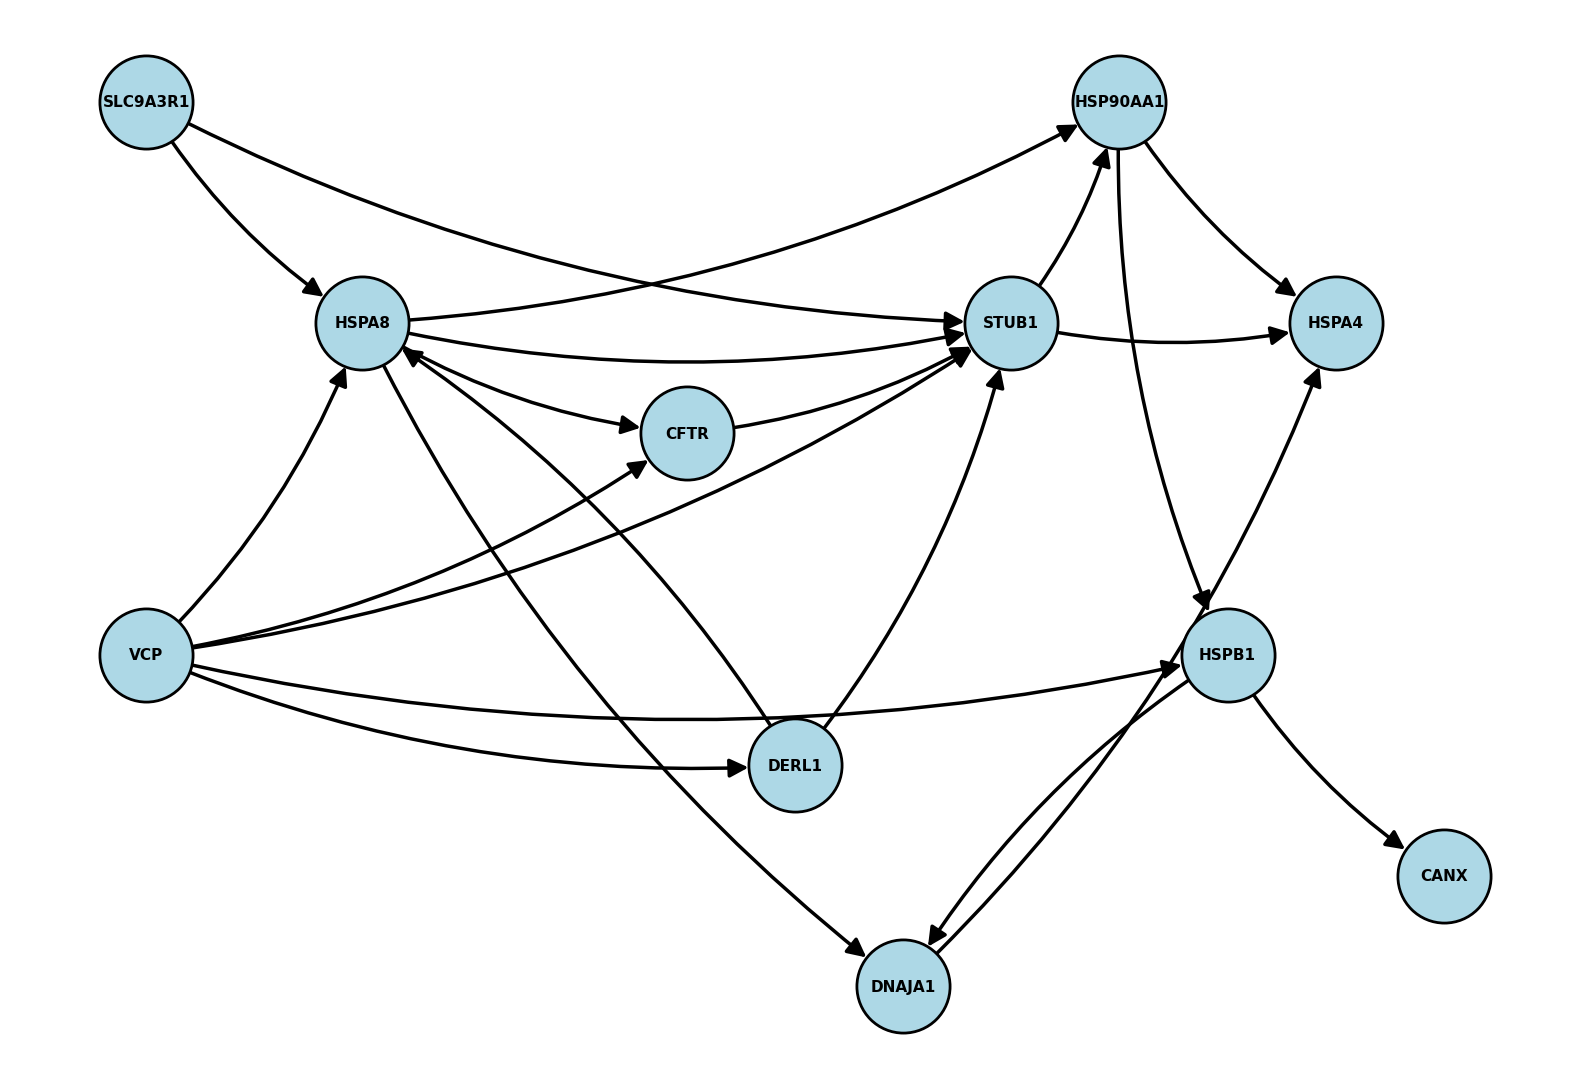

In [90]:
import networkx as nx
import matplotlib.pyplot as plt

# Exact learned Bayesian network structure
learned_edges = [
    ("CFTR", "STUB1"),
    ("HSPA8", "STUB1"),
    ("HSPA8", "CFTR"),
    ("HSPA8", "DNAJA1"),
    ("HSPA8", "HSP90AA1"),
    ("SLC9A3R1", "STUB1"),
    ("SLC9A3R1", "HSPA8"),
    ("VCP", "STUB1"),
    ("VCP", "HSPA8"),
    ("VCP", "CFTR"),
    ("VCP", "DERL1"),
    ("VCP", "HSPB1"),
    ("STUB1", "HSPA4"),
    ("STUB1", "HSP90AA1"),
    ("DERL1", "STUB1"),
    ("DERL1", "HSPA8"),
    ("HSP90AA1", "HSPA4"),
    ("HSP90AA1", "HSPB1"),
    ("DNAJA1", "HSPA4"),
    ("HSPB1", "DNAJA1"),
    ("HSPB1", "CANX")
]

# Create directed graph
G = nx.DiGraph()
G.add_edges_from(learned_edges)

# Spread-out positions
pos = {
    "SLC9A3R1": (-5, 4),
    "HSPA8": (-3, 2),
    "VCP": (-5, -1),
    "CFTR": (0, 1),
    "DERL1": (1, -2),
    "STUB1": (3, 2),
    "HSP90AA1": (4, 4),
    "HSPB1": (5, -1),
    "DNAJA1": (2, -4),
    "HSPA4": (6, 2),
    "CANX": (7, -3)
}

plt.figure(figsize=(16, 11))

# Nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4500,
    node_color="lightblue",
    edgecolors="black",
    linewidths=2
)

# Labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold"
)

# Edges with VERY visible arrows
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=28,
    width=2.5,
    edge_color="black",
    node_size=4500,
    connectionstyle="arc3,rad=0.12",
    min_source_margin=15,
    min_target_margin=20
)

plt.axis("off")
plt.tight_layout()

# Save high-resolution image
plt.savefig(
    "expanded_bayesian_network.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [91]:
from pgmpy.estimators import BIC

bic_initial = BIC(pgm_data)

initial_bic_score = bic_initial.score(pgm_model)

print("Initial model BIC score:", initial_bic_score)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


Initial model BIC score: -390.64851563482955


In [93]:
bic_expanded = BIC(expanded_publication_matrix[expanded_proteins])

expanded_bic_score = bic_expanded.score(expanded_pgm)

print("Expanded model BIC score:", expanded_bic_score)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


Expanded model BIC score: -4528.55744364114


In [94]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BIC

empty_initial = DiscreteBayesianNetwork()
empty_initial.add_nodes_from(pgm_data.columns)

bic_initial = BIC(pgm_data)

empty_initial_bic = bic_initial.score(empty_initial)

print("Learned model BIC:", initial_bic_score)
print("Empty model BIC:", empty_initial_bic)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


Learned model BIC: -390.64851563482955
Empty model BIC: -453.8432980048769


In [95]:
empty_expanded = DiscreteBayesianNetwork()
empty_expanded.add_nodes_from(expanded_publication_matrix[expanded_proteins].columns)

bic_expanded = BIC(expanded_publication_matrix[expanded_proteins])

empty_expanded_bic = bic_expanded.score(empty_expanded)

print("Learned model BIC:", expanded_bic_score)
print("Empty model BIC:", empty_expanded_bic)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


Learned model BIC: -4528.55744364114
Empty model BIC: -5278.474838508759


In [96]:
import numpy as np
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BIC

n_bootstrap = 100
rng = np.random.default_rng(42)

edge_counts = {}

for i in range(n_bootstrap):
    bootstrap_data = pgm_data.sample(
        n=len(pgm_data),
        replace=True,
        random_state=int(rng.integers(0, 1_000_000))
    ).reset_index(drop=True)

    estimator = HillClimbSearch(bootstrap_data)
    structure = estimator.estimate(
        scoring_method=BIC(bootstrap_data)
    )

    for edge in structure.edges():
        edge_counts[edge] = edge_counts.get(edge, 0) + 1

stability_initial = pd.DataFrame(
    [
        {
            "Edge": f"{source} -> {target}",
            "Count": count,
            "Stability": count / n_bootstrap
        }
        for (source, target), count in edge_counts.items()
    ]
).sort_values("Stability", ascending=False)

stability_initial

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


...

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

,Edge,Count,Stability
2,SLC9A3R1 -> STUB1,74,0.74
4,STUB1 -> VCP,56,0.56
9,SLC9A3R1 -> CFTR,48,0.48
6,STUB1 -> HSPA8,46,0.46
8,VCP -> STUB1,44,0.44
1,CFTR -> VCP,42,0.42
5,STUB1 -> DERL1,41,0.41
13,DERL1 -> STUB1,40,0.40
3,SLC9A3R1 -> VCP,33,0.33
20,DERL1 -> HSPA8,32,0.32


In [97]:
n_bootstrap = 100
rng = np.random.default_rng(42)

edge_counts = {}

for i in range(n_bootstrap):
    bootstrap_data = expanded_publication_matrix[expanded_proteins].sample(
        n=len(expanded_publication_matrix),
        replace=True,
        random_state=int(rng.integers(0, 1_000_000))
    ).reset_index(drop=True)

    estimator = HillClimbSearch(bootstrap_data)
    structure = estimator.estimate(
        scoring_method=BIC(bootstrap_data)
    )

    for edge in structure.edges():
        edge_counts[edge] = edge_counts.get(edge, 0) + 1

stability_expanded = pd.DataFrame(
    [
        {
            "Edge": f"{source} -> {target}",
            "Count": count,
            "Stability": count / n_bootstrap
        }
        for (source, target), count in edge_counts.items()
    ]
).sort_values("Stability", ascending=False)

stability_expanded

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


...

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'CFTR': 'N', 'HSPA8': 'N', 'SLC9A3R1': 'N', 'VCP': 'N', 'STUB1': 'N', 'DERL1': 'N', 'HSP90AA1': 'N', 'HSPA4': 'N', 'DNAJA1': 'N', 'HSPB1': 'N', 'CANX': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

,Edge,Count,Stability
2,HSPA8 -> VCP,96,0.96
3,SLC9A3R1 -> VCP,94,0.94
0,CFTR -> VCP,84,0.84
7,DERL1 -> VCP,76,0.76
5,STUB1 -> VCP,73,0.73
...,...,...,...
83,HSP90AA1 -> DERL1,1,0.01
82,HSPA4 -> DERL1,1,0.01
80,SLC9A3R1 -> HSPA4,1,0.01
71,SLC9A3R1 -> HSPB1,1,0.01
